KUMPULAN LIBRARY PYTHON :
1. pandas
2. matplotlib
3. sastrawi
4. wordcloud, Menggambarkan metadata kumpulan kata kunci/keywords pada sebuah dokumen --> alt : Tweepy, Pandas, Re(regex), Time, Json, matplotlib
5. numpy, melakukan operasi komputasi untuk tipe data numerik seperti tipe data operasi aritmatika atau operasi lainnya yang dapat diterapkan pada vektor atau matriks
6. sklearn --> 
a. naive bayes(GaussianNB), 
b. model selection (RepeatedStratifiedKFold, GridSearchCV, StratifiedKFold), 
c. metrics (confusion_matrix, classification_report) 

In [137]:
import pandas as pd
import matplotlib.pyplot as plt
import Sastrawi
from wordcloud import WordCloud
import numpy as np

A. CRAWLING DATA

In [138]:
df = pd.read_csv('data_real.csv', index_col=0)
df.head()

,Unnamed: 0,Ulasan,Rating,Kategori,Nama Produk,Id Produk,Terjual,Id_Toko,Url,label
0,59,Pesanan gx sesuai dgn yg d gambar,2,pertukangan,Isi Staples Tembak 8 mm best guard,133507638,545,1461393,https://www.tokopedia.com/timurjaya46/isi-stap...,0
1,70,Pengiriman dan respon super cepat. Tpi barang ...,2,pertukangan,Isi Staples Tembak 8 mm best guard,133507638,545,1461393,https://www.tokopedia.com/timurjaya46/isi-stap...,0
2,95,barang yg dikirim tidak sesuai pesanan,1,pertukangan,Isi Staples Tembak 8 mm best guard,133507638,545,1461393,https://www.tokopedia.com/timurjaya46/isi-stap...,0
3,117,"Php, bilang isi ada diseskripsi pas dipesen be...",1,pertukangan,steples tembak / staples tembak kenmaster PROM...,88842566,45,1102298,https://www.tokopedia.com/cahayabelawa/steples...,0
4,153,barang jelek copot&#34; terus tmpat taro isinya,2,pertukangan,Staple Gun / Staples Tembak / Staples Jok / He...,209226141,171,580197,https://www.tokopedia.com/hmhhardware/staple-g...,0


MELAKUKAN COPY DATA AGAR DATA ASLI TIDAK TERGANGGU

In [139]:
df_copy = df.copy()

2. LABELING

In [140]:
label = []
for index, row in df_copy.iterrows():
  if row["Rating"] == 1 or row["Rating"] == 2:
    label.append(0)
  else:
    label.append(1)

df_copy["label"] = label

In [141]:
df_copy.head()

,Unnamed: 0,Ulasan,Rating,Kategori,Nama Produk,Id Produk,Terjual,Id_Toko,Url,label
0,59,Pesanan gx sesuai dgn yg d gambar,2,pertukangan,Isi Staples Tembak 8 mm best guard,133507638,545,1461393,https://www.tokopedia.com/timurjaya46/isi-stap...,0
1,70,Pengiriman dan respon super cepat. Tpi barang ...,2,pertukangan,Isi Staples Tembak 8 mm best guard,133507638,545,1461393,https://www.tokopedia.com/timurjaya46/isi-stap...,0
2,95,barang yg dikirim tidak sesuai pesanan,1,pertukangan,Isi Staples Tembak 8 mm best guard,133507638,545,1461393,https://www.tokopedia.com/timurjaya46/isi-stap...,0
3,117,"Php, bilang isi ada diseskripsi pas dipesen be...",1,pertukangan,steples tembak / staples tembak kenmaster PROM...,88842566,45,1102298,https://www.tokopedia.com/cahayabelawa/steples...,0
4,153,barang jelek copot&#34; terus tmpat taro isinya,2,pertukangan,Staple Gun / Staples Tembak / Staples Jok / He...,209226141,171,580197,https://www.tokopedia.com/hmhhardware/staple-g...,0


3. PREPROCESSING TEXT

In [142]:
# Mengubah text menjadi Lower(huruf kecil)
df_copy['Ulasan'] = df_copy['Ulasan'].str.lower()

3.1 NORMALISASI --> NORMALISASI KATA PADA PROGRAM

In [143]:
norm = {" dgn " : " dengan ",
        " gue " : " saya ", 
        " bgmn " : " bagaimana ", 
        " tdk " : " tidak ", 
        " blum " : " belum ", 
        " mantaaaaaaaappp " : " bagus ", 
        " josss " : " bagus ", 
        " thanks " : " terima kasih ", 
        " fast " : " cepat ", 
        " dg " : " dengan ", 
        " trims " : " terima kasih ", 
        " brg " : " barang ", 
        " gx " : " tidak ", 
        " recommended " : " rekomen ", 
        " recomend " : " rekomen ", 
        " good " : " bagus ", 
        " dgn " : " dengan "
        }

def normalisasi(str_text):
  for i in norm:
    str_text = str_text.replace(i, norm[i])
  return str_text
  
df_copy['Ulasan'] = df_copy['Ulasan'].apply(lambda x: normalisasi(x))

In [144]:
df_copy.head()

,Unnamed: 0,Ulasan,Rating,Kategori,Nama Produk,Id Produk,Terjual,Id_Toko,Url,label
0,59,pesanan tidak sesuai dengan yg d gambar,2,pertukangan,Isi Staples Tembak 8 mm best guard,133507638,545,1461393,https://www.tokopedia.com/timurjaya46/isi-stap...,0
1,70,pengiriman dan respon super cepat. tpi barang ...,2,pertukangan,Isi Staples Tembak 8 mm best guard,133507638,545,1461393,https://www.tokopedia.com/timurjaya46/isi-stap...,0
2,95,barang yg dikirim tidak sesuai pesanan,1,pertukangan,Isi Staples Tembak 8 mm best guard,133507638,545,1461393,https://www.tokopedia.com/timurjaya46/isi-stap...,0
3,117,"php, bilang isi ada diseskripsi pas dipesen be...",1,pertukangan,steples tembak / staples tembak kenmaster PROM...,88842566,45,1102298,https://www.tokopedia.com/cahayabelawa/steples...,0
4,153,barang jelek copot&#34; terus tmpat taro isinya,2,pertukangan,Staple Gun / Staples Tembak / Staples Jok / He...,209226141,171,580197,https://www.tokopedia.com/hmhhardware/staple-g...,0


3.2 STOPWORDS --> KATA-KATA TANPA MAKNA NAMUN SERING DIGUNAKAN

In [145]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory, StopWordRemover, ArrayDictionary
more_stop_words = []

stop_words = StopWordRemoverFactory().get_stop_words()

negation = ['tidak', 'bukan', 'belum', 'jangan']
for word in negation:
  if word in stop_words:
    stop_words.remove(word)

new_array = ArrayDictionary(stop_words)
stop_words_remover_new = StopWordRemover(new_array)

def stopword(str_text):
  str_text = stop_words_remover_new.remove(str_text)
  return str_text

df_copy['Ulasan'] = df_copy['Ulasan'].apply(lambda x: stopword(x))
df_copy.head()

,Unnamed: 0,Ulasan,Rating,Kategori,Nama Produk,Id Produk,Terjual,Id_Toko,Url,label
0,59,pesanan tidak sesuai yg d gambar,2,pertukangan,Isi Staples Tembak 8 mm best guard,133507638,545,1461393,https://www.tokopedia.com/timurjaya46/isi-stap...,0
1,70,pengiriman respon super cepat. tpi barang tida...,2,pertukangan,Isi Staples Tembak 8 mm best guard,133507638,545,1461393,https://www.tokopedia.com/timurjaya46/isi-stap...,0
2,95,barang yg dikirim tidak sesuai pesanan,1,pertukangan,Isi Staples Tembak 8 mm best guard,133507638,545,1461393,https://www.tokopedia.com/timurjaya46/isi-stap...,0
3,117,"php, bilang isi diseskripsi pas dipesen berbed...",1,pertukangan,steples tembak / staples tembak kenmaster PROM...,88842566,45,1102298,https://www.tokopedia.com/cahayabelawa/steples...,0
4,153,barang jelek copot&#34; terus tmpat taro isinya,2,pertukangan,Staple Gun / Staples Tembak / Staples Jok / He...,209226141,171,580197,https://www.tokopedia.com/hmhhardware/staple-g...,0


3.3 TOKENIZE

In [146]:
tokenized = df_copy['Ulasan'].apply(lambda x:x.split())
tokenized

0                [pesanan, tidak, sesuai, yg, d, gambar]
1      [pengiriman, respon, super, cepat., tpi, baran...
2          [barang, yg, dikirim, tidak, sesuai, pesanan]
3      [php,, bilang, isi, diseskripsi, pas, dipesen,...
4      [barang, jelek, copot&#34;, terus, tmpat, taro...
                             ...                        
995           [bagus, memuaskan., packing, bagus, cepat]
996              [mantap, pengiriman, cepat, recomended]
997                        [pengiriman, cepat., lumayan]
998              [belom, dicoba, semoga, oke, barangnya]
999    [barang, cukup, bagus,, respon, bagus., gak, m...
Name: Ulasan, Length: 1925, dtype: object

4. STEMMING --> PENYEDERHAAN KATA 

In [147]:
# from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# def stemming(Ulasan):
#   factory = StemmerFactory()
#   stemmer = factory.create_stemmer()
#   do = []
#   for w in Ulasan:
#     dt = stemmer.stem(w)
#     do.append(dt)
#   d_clean = []
#   d_clean = " ".join(do)
#   print(d_clean)
#   return d_clean

# tokenized = tokenized.apply(stemming)

# tokenized.to_csv('databersih2.csv', index=False)
# data_clean = pd.read_csv('databersih2.csv', encoding='latin1')
# data_clean.head()

4.1 MENGGABUNGKAN KEDUA ATRIBUT

In [148]:
at1 = pd.read_csv('databersih2.csv')
at2 = pd.read_csv('data_real.csv')
att2 = at2[[ 'Rating', 'label']]

result = pd.concat([at1, att2], axis=1)

In [149]:
result.tail()

,Ulasan,Rating,label
1920,bagus muas packing bagus cepat,4,1
1921,mantap kirim cepat recomended,5,1
1922,kirim cepat lumayan,4,1
1923,bom coba moga oke barang,4,1
1924,barang cukup bagus respon bagus gak manual gan...,3,1


5. MENGHITUNG KATA DENGAN TF-IDF (TERM FREQUENCY - INVERSE DOCUMENT FREQUENCY)

In [150]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

In [151]:
Ulasan = result['Ulasan']

In [152]:
Ulasan.isnull().sum()

np.int64(6)

In [153]:
Ulasan = Ulasan.fillna('Kada da Komentar')

In [154]:
cv = CountVectorizer()
term_fit = cv.fit(Ulasan)

print(len(term_fit.vocabulary_))

2867


In [155]:
term_fit.vocabulary_

{'pesan': 1990,
 'tidak': 2643,
 'sesuai': 2331,
 'yg': 2854,
 'gambar': 917,
 'kirim': 1315,
 'respon': 2171,
 'super': 2505,
 'cepat': 570,
 'tpi': 2696,
 'barang': 300,
 'kuat': 1386,
 'tembus': 2584,
 'jok': 1176,
 'motor': 1682,
 'php': 1996,
 'bilang': 410,
 'isi': 1115,
 'skripsi': 2390,
 'pas': 1930,
 'sen': 2307,
 'beda': 350,
 'mubajir': 1694,
 'rp50': 2201,
 '000': 1,
 'nyata': 1828,
 'ga': 903,
 'cocok': 600,
 'jelek': 1157,
 'copot': 619,
 '34': 69,
 'terus': 2608,
 'tmpat': 2670,
 'taro': 2558,
 'beli': 361,
 'staples': 2462,
 'gak': 914,
 'jual': 1183,
 'sekali': 2284,
 'pake': 1908,
 'ckckck': 586,
 'baik': 276,
 'kalau': 1214,
 'mau': 1595,
 'ngirim': 1774,
 'periksa': 1984,
 'dulu': 821,
 'gan': 922,
 'kondisi': 1355,
 'layak': 1436,
 'apa': 217,
 'gitu': 960,
 'loh': 1488,
 'karat': 1234,
 'semua': 2306,
 'produk': 2058,
 'order': 1872,
 'prohex': 2062,
 'brg': 469,
 'sdh': 2264,
 'terima': 2600,
 'buat': 489,
 'masang': 1585,
 'datang': 672,
 'cacat': 525,
 'guna': 

In [156]:
# Kolom PERTAMA adalah JUMLAH DOKUMEN
# Kolom KEDUA adalah LETAK KATA
# Kolom KETIGA adalah HASIL DARI TF 

term_frequency_all = term_fit.transform(Ulasan)
print(term_frequency_all)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 16494 stored elements and shape (1925, 2867)>
  Coords	Values
  (0, 917)	1
  (0, 1990)	1
  (0, 2331)	1
  (0, 2643)	1
  (0, 2854)	1
  (1, 300)	1
  (1, 570)	1
  (1, 917)	1
  (1, 1176)	1
  (1, 1315)	1
  (1, 1386)	1
  (1, 1682)	1
  (1, 2171)	1
  (1, 2331)	1
  (1, 2505)	1
  (1, 2584)	1
  (1, 2643)	2
  (1, 2696)	1
  (2, 300)	1
  (2, 1315)	1
  (2, 1990)	1
  (2, 2331)	1
  (2, 2643)	1
  (2, 2854)	1
  (3, 1)	1
  :	:
  (1924, 639)	1
  (1924, 738)	1
  (1924, 901)	1
  (1924, 914)	2
  (1924, 922)	1
  (1924, 962)	1
  (1924, 995)	1
  (1924, 1033)	1
  (1924, 1466)	1
  (1924, 1576)	1
  (1924, 1718)	1
  (1924, 1807)	1
  (1924, 1912)	1
  (1924, 1933)	1
  (1924, 2003)	1
  (1924, 2171)	1
  (1924, 2240)	1
  (1924, 2264)	1
  (1924, 2294)	1
  (1924, 2380)	1
  (1924, 2521)	3
  (1924, 2583)	1
  (1924, 2660)	1
  (1924, 2695)	1
  (1924, 2784)	1


In [157]:
ulasan_tf = Ulasan[100]
print(ulasan_tf)

cashing gak nempel batre drop apesss


In [158]:
term_frequency = term_fit.transform([ulasan_tf])
print(term_frequency)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 6 stored elements and shape (1, 2867)>
  Coords	Values
  (0, 219)	1
  (0, 329)	1
  (0, 550)	1
  (0, 810)	1
  (0, 914)	1
  (0, 1743)	1


In [159]:
dokumen = term_fit.transform(Ulasan)
tfidf_transformer = TfidfTransformer().fit(dokumen)
print(tfidf_transformer.idf_)

tfidf = tfidf_transformer.transform(term_frequency)
print(tfidf)

[7.87005341 7.87005341 7.87005341 ... 7.87005341 7.87005341 7.87005341]
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 6 stored elements and shape (1, 2867)>
  Coords	Values
  (0, 219)	0.4846022395739582
  (0, 329)	0.36478190711874964
  (0, 550)	0.4846022395739582
  (0, 810)	0.4169546712977476
  (0, 914)	0.2530045738175209
  (0, 1743)	0.3992405124095224


6. VISUALISASI (NLP - NATURAL LANGUAGE PROCESSING)

In [160]:
train_s0 = df_copy[df_copy["label"] == 0]

In [161]:
train_s0["Ulasan"] = train_s0["Ulasan"].fillna("Kada da komentar")

C:\Users\hazurr\AppData\Local\Temp\ipykernel_12144\4057942965.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_s0["Ulasan"] = train_s0["Ulasan"].fillna("Kada da komentar")


In [162]:
train_s0.head()

,Unnamed: 0,Ulasan,Rating,Kategori,Nama Produk,Id Produk,Terjual,Id_Toko,Url,label
0,59,pesanan tidak sesuai yg d gambar,2,pertukangan,Isi Staples Tembak 8 mm best guard,133507638,545,1461393,https://www.tokopedia.com/timurjaya46/isi-stap...,0
1,70,pengiriman respon super cepat. tpi barang tida...,2,pertukangan,Isi Staples Tembak 8 mm best guard,133507638,545,1461393,https://www.tokopedia.com/timurjaya46/isi-stap...,0
2,95,barang yg dikirim tidak sesuai pesanan,1,pertukangan,Isi Staples Tembak 8 mm best guard,133507638,545,1461393,https://www.tokopedia.com/timurjaya46/isi-stap...,0
3,117,"php, bilang isi diseskripsi pas dipesen berbed...",1,pertukangan,steples tembak / staples tembak kenmaster PROM...,88842566,45,1102298,https://www.tokopedia.com/cahayabelawa/steples...,0
4,153,barang jelek copot&#34; terus tmpat taro isinya,2,pertukangan,Staple Gun / Staples Tembak / Staples Jok / He...,209226141,171,580197,https://www.tokopedia.com/hmhhardware/staple-g...,0


In [163]:
from wordcloud import WordCloud

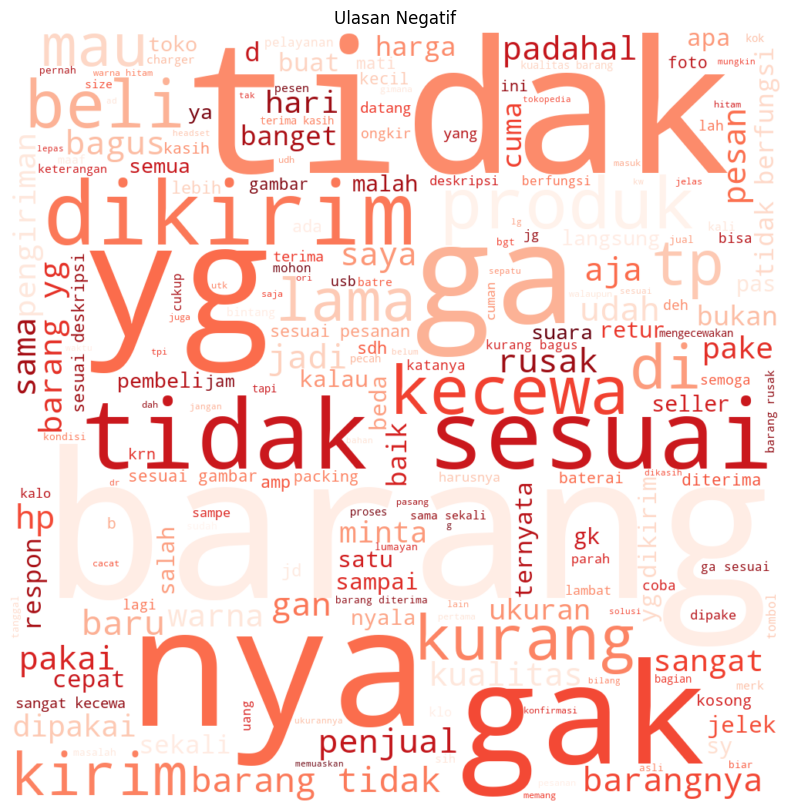

In [164]:
all_text_s0 = ' '.join(word for word in train_s0["Ulasan"])
wordcloud = WordCloud(colormap='Reds', width=1000, height=1000, mode='RGBA', background_color="white").generate(all_text_s0)
plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Ulasan Negatif")
plt.margins(x=0, y=0)
plt.show()

In [165]:
train_s1 = df_copy[df_copy["label"] == 1]

In [166]:
train_s1["Ulasan"] = train_s1["Ulasan"].fillna("Kada da komentar")

C:\Users\hazurr\AppData\Local\Temp\ipykernel_12144\4124165800.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_s1["Ulasan"] = train_s1["Ulasan"].fillna("Kada da komentar")


In [167]:
train_s1.head()

,Unnamed: 0,Ulasan,Rating,Kategori,Nama Produk,Id Produk,Terjual,Id_Toko,Url,label
0,1,barang sesuai pesanan cepat,5,pertukangan,Staples Dekorasi Staples Kayu + Refill 8mm - S...,418660637,1,1740837,https://www.tokopedia.com/shakaonline87/staple...,1
1,2,barang bagus harga murah,5,pertukangan,STAPLE GUN ATS 3 WAY TACKER - STAPLES JOK TEMB...,416032545,11,1477109,https://www.tokopedia.com/juraganperkakas/stap...,1
2,3,paket rapi...mantap....cepat....sampe tujuan,5,pertukangan,STAPLE GUN ATS 3 WAY TACKER - STAPLES JOK TEMB...,416032545,11,1477109,https://www.tokopedia.com/juraganperkakas/stap...,1
3,4,saya puas barangnya,5,pertukangan,ALAT STAPLES TEMBAK &#40;AIR NAILER GUN&#41; O...,102279869,5,771395,https://www.tokopedia.com/kamarmesin/alat-stap...,1
4,5,responya luar biasa b mantap,5,pertukangan,Isi Refill Staples Jok Kulit Motor / Staple Gu...,190679689,787,969999,https://www.tokopedia.com/mitrapersada/isi-ref...,1


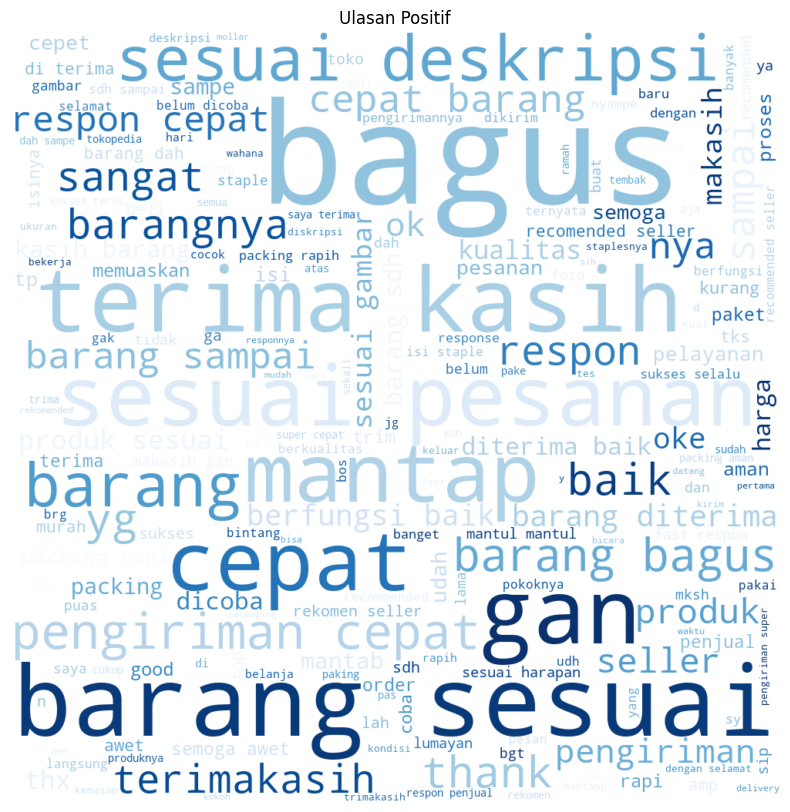

In [168]:
all_text_s1 = ' '.join(word for word in train_s1["Ulasan"])
wordcloud = WordCloud(colormap='Blues', width=1000, height=1000, mode='RGBA', background_color="white").generate(all_text_s1)
plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Ulasan Positif")
plt.margins(x=0, y=0)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

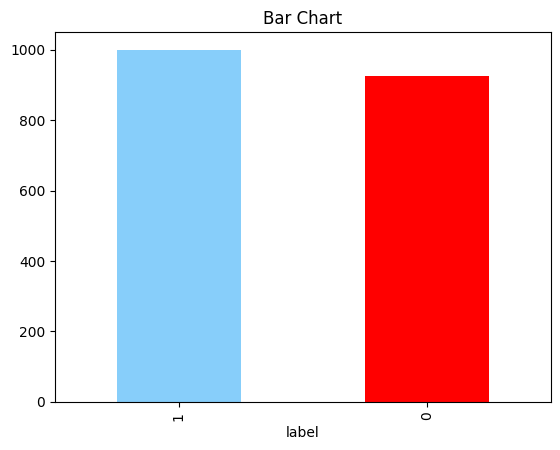

In [169]:
sent_data = df_copy["label"].value_counts(sort=True)
sent_data.plot(kind='bar', color=['lightskyblue', 'red'])
plt.title("Bar Chart")
plt.show

7. SPLIT DATA (TF-IDF --> TERM FREQUENCY - INVERSE DOCUMENT FREQUENCY)

In [170]:
result['Ulasan'] = result['Ulasan'].fillna("Kada daa komentar")

In [171]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(result['Ulasan'], result['label'],
                                                    test_size=0.1, stratify=result['label'], random_state=30)

In [172]:
import numpy as np

In [173]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(decode_error='replace', encoding='utf-8')

In [174]:
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(1732, 2731)
(193, 2731)


In [175]:
X_train = X_train.toarray()

In [176]:
X_test = X_test.toarray()

8. MACHINE LEARNING (NAIVE BAYES CLASSIFIER)

In [179]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

In [180]:
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import GridSearchCV

cv_method = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=999)

params_NB = {'var_smoothing': np.logspace(0, -9, num=100)}
gscv_nb = GridSearchCV(estimator = nb,
                       param_grid = params_NB,
                       cv = cv_method,
                       verbose = 1,
                       scoring = 'accuracy')

gscv_nb.fit(X_train, y_train)
gscv_nb.best_params_

Fitting 15 folds for each of 100 candidates, totalling 1500 fits


{'var_smoothing': np.float64(0.006579332246575682)}

In [181]:
nb = GaussianNB(var_smoothing=0.006579332246575682)

In [ ]:
nb.fit(X_train, y_train)

In [183]:
y_pred_nb = nb.predict(X_test)

9. CONFUSION MATRIX

In [185]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report, roc_curve, RocCurveDisplay

In [ ]:
print('----- Confusion Matrix -----')
print(confusion_matrix(y_test, y_pred_nb))

print('----- Classification Report -----')
print(classification_report(y_test, y_pred_nb))

In [ ]:
RocCurveDisplay.from_estimator(nb, X_test, y_test)